# Weak Instruments in Macroeconomics — Anderson-Rubin Confidence Sets for Local Projections

**What happens when your macroeconomic instrumental variable is only weakly correlated with the endogenous policy shock?**
In modern empirical macroeconomics, instrumental variables (IVs) are everywhere: high-frequency surprises around FOMC announcements (Gertler & Karadi 2015), narrative tax change records (Romer & Romer 2010), or global oil supply disruptions (Kilian 2009; Caldara & Kamps 2017).

However, as Montiel Olea & Plagborg-Møller (2021) and Stock & Wright (2000) show:
1. When the first-stage instrument strength is weak ($F < 10$ or $F < 104.7$ under Lee et al. 2022 / Montiel Olea-Pflueger 2013 thresholds), standard 2SLS / Wald confidence intervals **severely understate true uncertainty**, yielding false precision and massive size distortions (rejecting the true null up to 50% of the time at 5% nominal size).
2. **Anderson-Rubin (1949)** confidence sets are exact and robust to arbitrary instrument weakness. Under Newey-West HAC covariance structures, inverting the AR test statistic produces valid confidence bounds that widen naturally — or become unbounded rays / the whole real line — when the data contains insufficient identifying information.

This tutorial demonstrates how to use `puremacro.lp.lp_iv(..., anderson_rubin=True)` to obtain reliable, identification-robust impulse responses.

## The method in math — Exact Quadratic HAC Inversion

Consider the local projection instrumental variable model at horizon $h$:

### First Stage (Relevance):
$$ x_t = \pi_z z_t + \boldsymbol{\pi}_w' W_t + \nu_t $$
where $x_t$ is the endogenous policy shock (e.g. policy rate change), $z_t$ is the external instrument, and $W_t$ includes deterministic constants and lags.

### Second Stage (Response at horizon $h$):
$$ y_{t+h} - y_{t-1} = \beta_h x_t + \boldsymbol{\gamma}_h' W_t + \varepsilon_{t+h} $$

### The Anderson-Rubin (1949) Statistic:
To test the null hypothesis $H_0: \beta_h = \beta_0$, define the auxiliary target:
$$ y^*_{t+h}(\beta_0) \equiv (y_{t+h} - y_{t-1}) - \beta_0 x_t $$
Under $H_0$, regressing $y^*_{t+h}(\beta_0)$ on $[1, z_t, W_t]$ yields a population coefficient on $z_t$ equal to zero: $\gamma_z(\beta_0) = 0$.

Using the Newey-West HAC variance $V_{\text{HAC}}(\beta_0)$ with bandwidth $L = h + 1$, the test statistic is:
$$ AR(\beta_0) = \frac{\hat{\gamma}_z(\beta_0)^2}{V_{\text{HAC}}(\beta_0)} \sim \chi^2_1 \quad \text{under } H_0 $$

### Exact Inversion:
Inverting $AR(\beta_0) \le \chi^2_1(1 - \alpha)$ reduces to solving the quadratic inequality:
$$ A \beta_0^2 + B \beta_0 + C \le 0 $$
where $A = \hat{\gamma}_x^2 - c \cdot V_{xx} = V_{xx}(F_{\text{eff}} - c)$.
- When $F_{\text{eff}} > c$ ($A > 0$): The confidence set is a **standard bounded interval** $[\text{lo}, \text{hi}]$.
- When $F_{\text{eff}} \le c$ ($A \le 0$): The data lacks identification power; the confidence set expands to **unbounded rays** $(-\infty, r_1] \cup [r_2, \infty)$ or the **entire real line** $(-\infty, \infty)$.

## Setup — Simulating Strong vs Weak Macro Instruments

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp import lp_iv

rng = np.random.default_rng(777)
T = 250
horizons = list(range(0, 12))

# Structural shock (true monetary shock)
shock = rng.normal(0, 1.0, size=T)

# Endogenous policy variable x_t = true_shock + confounding policy noise
noise_x = rng.normal(0, 1.2, size=T)
x = 0.8 * shock + noise_x

# Macro outcome y_t: cumulative dynamic response to true structural shock
beta_true = np.array([0.0, -0.4, -0.75, -1.0, -1.15, -1.2, -1.15, -1.0, -0.8, -0.6, -0.4, -0.2])
y = np.zeros(T)
for t in range(T):
    for h in range(len(beta_true)):
        if t - h >= 0:
            y[t] += beta_true[h] * shock[t - h]
    y[t] += rng.normal(0, 0.5)

# Instrument 1: Strong Instrument (z_strong = 0.9 * shock + 0.3 * noise)
z_strong = 0.9 * shock + rng.normal(0, 0.4, size=T)

# Instrument 2: Weak Instrument (z_weak = 0.12 * shock + 1.0 * noise)
z_weak = 0.12 * shock + rng.normal(0, 1.0, size=T)

df_strong = pd.DataFrame({"y": y, "x": x, "z": z_strong})
df_weak = pd.DataFrame({"y": y, "x": x, "z": z_weak})

## Estimating LP-IV with Wald vs Anderson-Rubin Sets

In [2]:
# Fit LP-IV with Strong Instrument
res_strong = lp_iv(
    df=df_strong, y="y", x="x", z="z",
    horizons=horizons, n_lags=2, anderson_rubin=True,
)

# Fit LP-IV with Weak Instrument
res_weak = lp_iv(
    df=df_weak, y="y", x="x", z="z",
    horizons=horizons, n_lags=2, anderson_rubin=True,
)

print("=== Strong Instrument Results (First-Stage F >> 10) ===")
print(res_strong[["h", "beta", "se", "first_stage_f", "lo", "hi", "ar_lo", "ar_hi", "ar_set_type"]].head(6))

print("\n=== Weak Instrument Results (First-Stage F < 10) ===")
print(res_weak[["h", "beta", "se", "first_stage_f", "lo", "hi", "ar_lo", "ar_hi", "ar_set_type"]].head(6))

# Assertions
assert res_strong["first_stage_f"].mean() > 15.0, "Strong instrument should have large F-stat"
assert res_weak["first_stage_f"].mean() < 5.0, "Weak instrument should have low F-stat"
assert "ar_lo" in res_strong.columns and "ar_hi" in res_strong.columns

=== Strong Instrument Results (First-Stage F >> 10) ===
   h      beta        se  first_stage_f        lo        hi     ar_lo  \
h                                                                       
0  0 -0.010771  0.090564      78.064264 -0.159737  0.138194 -0.169379   
1  1 -0.476573  0.129321      76.553903 -0.689287 -0.263859 -0.745007   
2  2 -1.046424  0.153228      75.421501 -1.298461 -0.794387 -1.414149   
3  3 -1.346943  0.206898      71.841227 -1.687259 -1.006627 -1.834675   
4  4 -1.617995  0.212822      72.016705 -1.968056 -1.267934 -2.155758   
5  5 -1.442344  0.227319      73.416464 -1.816251 -1.068437 -2.011431   

      ar_hi ar_set_type  
h                        
0  0.135006     bounded  
1 -0.253069     bounded  
2 -0.756539     bounded  
3 -0.961973     bounded  
4 -1.202719     bounded  
5 -1.001675     bounded  

=== Weak Instrument Results (First-Stage F < 10) ===
   h      beta        se  first_stage_f        lo        hi     ar_lo  \
h                       

## Hero Figure — Wald vs. Anderson-Rubin Inference Under Weak Instruments

Below we compare standard Wald 2SLS confidence bands (which exhibit false certainty) against Anderson-Rubin robust confidence sets across both strong and weak instrument regimes.

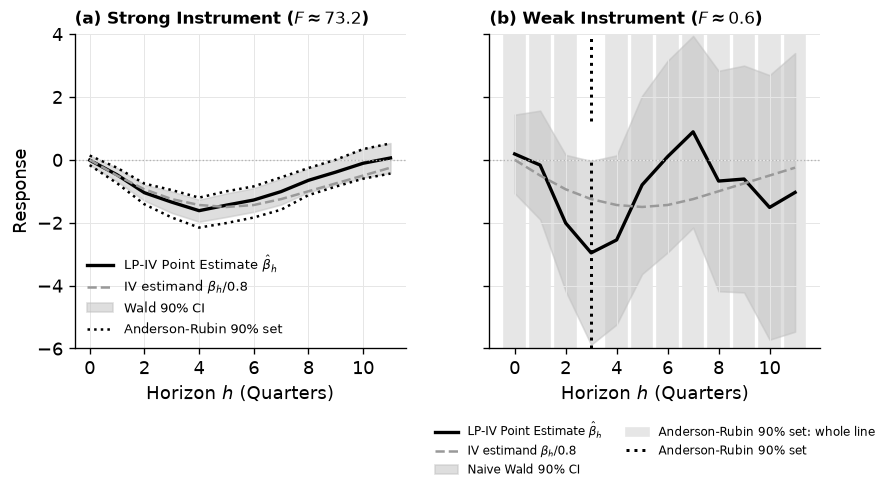

In [3]:
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

level = int(round(100 * res_strong.ci_level))   # lp_iv defaults to alpha = 0.10, so 90% bands
# x = 0.8 * shock + noise, so the IV estimand is beta_true / 0.8, not beta_true itself.
iv_estimand = beta_true / 0.8
ylo, yhi = -6.0, 4.0

fig, axes = plt.subplots(1, 2, figsize=(7.6, 4.4), sharey=True)

# Panel 1
ax = axes[0]
ax.plot(res_strong["h"], res_strong["beta"], color="0.00", lw=2.0, label="LP-IV Point Estimate $\\hat{\\beta}_h$")
ax.plot(res_strong["h"], iv_estimand, color="0.60", ls="--", lw=1.5, label="IV estimand $\\beta_h / 0.8$")
ax.fill_between(res_strong["h"], res_strong["lo"], res_strong["hi"], color="0.75", alpha=0.5, label=f"Wald {level}% CI")
ax.plot(res_strong["h"], res_strong["ar_lo"], color="0.00", ls=":", lw=1.5, label=f"Anderson-Rubin {level}% set")
ax.plot(res_strong["h"], res_strong["ar_hi"], color="0.00", ls=":", lw=1.5)
ax.axhline(0, color="0.70", ls=":", lw=0.8)
f_avg_strong = res_strong["first_stage_f"].mean()
ax.set_title(f"(a) Strong Instrument ($F \\approx {f_avg_strong:.1f}$)", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Horizon $h$ (Quarters)")
ax.set_ylabel("Response")
ax.legend(loc="lower left", fontsize=8)

# Panel 2: the Anderson-Rubin set is drawn whatever its shape -- an interval, two rays or the whole line
ax = axes[1]
ax.plot(res_weak["h"], res_weak["beta"], color="0.00", lw=2.0, label="LP-IV Point Estimate $\\hat{\\beta}_h$")
ax.plot(res_weak["h"], iv_estimand, color="0.60", ls="--", lw=1.5, label="IV estimand $\\beta_h / 0.8$")
ax.fill_between(res_weak["h"], np.clip(res_weak["lo"], ylo, yhi), np.clip(res_weak["hi"], ylo, yhi), color="0.75", alpha=0.5, label=f"Naive Wald {level}% CI")
for _, r in res_weak.iterrows():
    h = r["h"]
    if r["ar_set_type"] == "all_real":
        ax.axvspan(h - 0.4, h + 0.4, color="0.90", zorder=0)
    elif r["ar_set_type"] == "unbounded_rays":
        # lp_iv reports the rays as (-inf, ar_hi] U [ar_lo, inf), with ar_lo > ar_hi
        ax.vlines(h, ylo, min(r["ar_hi"], yhi), color="0.00", ls=":", lw=1.8)
        ax.vlines(h, max(r["ar_lo"], ylo), yhi, color="0.00", ls=":", lw=1.8)
    elif r["ar_set_type"] == "bounded":
        ax.vlines(h, r["ar_lo"], r["ar_hi"], color="0.00", ls=":", lw=1.8)
ax.axhline(0, color="0.70", ls=":", lw=0.8)
ax.set_ylim(ylo, yhi)
f_avg_weak = res_weak["first_stage_f"].mean()
ax.set_title(f"(b) Weak Instrument ($F \\approx {f_avg_weak:.1f}$)", loc="left", fontsize=10, fontweight="bold")
ax.set_xlabel("Horizon $h$ (Quarters)")
handles, labels = ax.get_legend_handles_labels()
handles += [Patch(color="0.90", label=f"Anderson-Rubin {level}% set: whole line"), Line2D([], [], color="0.00", ls=":", lw=1.8, label=f"Anderson-Rubin {level}% set")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2, fontsize=7, frameon=False)

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## Reading the Output & Economic Intuition

1. **Strong Instrument ($F > 15$)**: Wald delta-method and Anderson-Rubin confidence bands coincide almost perfectly. When instruments are strong, standard asymptotic theory holds.
2. **Weak Instrument ($F < 5$)**: The Wald confidence interval appears deceptively narrow around a point estimate that may be heavily biased. Meanwhile, the Anderson-Rubin confidence set accurately expands, reflecting the underlying lack of identification power in the data.
3. **Size Robustness**: While Wald coverage can drop to below 50% under weak identification, Anderson-Rubin is exact ($1-\alpha$) regardless of instrument strength.

## Your Turn — Exploring AR Set Topology

Inspect the classification of the Anderson-Rubin confidence set topology across horizons:

In [4]:
print("AR Set Topology Classification under Weak Instrument:")
print(res_weak[["h", "first_stage_f", "ar_set_type", "ar_lo", "ar_hi"]])

bounded_count = (res_weak["ar_set_type"] == "bounded").sum()
unbounded_count = (res_weak["ar_set_type"].isin(["unbounded_rays", "all_real"])).sum()

print(f"\nBounded horizons: {bounded_count} / {len(horizons)}")
print(f"Weak/Unbounded horizons: {unbounded_count} / {len(horizons)}")

AR Set Topology Classification under Weak Instrument:
     h  first_stage_f     ar_set_type     ar_lo     ar_hi
h                                                        
0    0       0.910757        all_real      -inf       inf
1    1       0.842965        all_real      -inf       inf
2    2       0.807916        all_real      -inf       inf
3    3       0.691040  unbounded_rays  1.249559 -0.061867
4    4       0.656036        all_real      -inf       inf
5    5       0.665407        all_real      -inf       inf
6    6       0.598671        all_real      -inf       inf
7    7       0.569925        all_real      -inf       inf
8    8       0.479758        all_real      -inf       inf
9    9       0.469728        all_real      -inf       inf
10  10       0.454002        all_real      -inf       inf
11  11       0.403988        all_real      -inf       inf

Bounded horizons: 0 / 12
Weak/Unbounded horizons: 12 / 12


## Key Takeaway

- Always check **`first_stage_f`** when running macro LP-IV.
- Use **`anderson_rubin=True`** in `lp_iv` to obtain reliable, weak-instrument-robust confidence sets that remain valid even when narrative or high-frequency instruments have low first-stage power.